# Automatización de preprocesamiento medianto pipelines

## 1. Análisis de la estrategia de imputación

En la primera parte del trabajo práctico se analizó la posibilidad de imputar algunos valores faltantes utilizando estadísticas calculadas por clase (Outcome).
- ¿Sería posible utilizar esta misma estrategia dentro de un pipeline que deba procesar pacientes nuevos?

No, **no sería posible**. La imputación condicionada por la clase Outcome requiere conocer la clase de cada paciente para decidir qué estadístico usar. Sin embargo, Outcome es la variable objetivo que el modelo tiene que predecir, y no esta disponible cuando se procesa un nuevo paciente. Utilizar la misma estrategia dentro de un pipeline implicaría usar la respuesta antes de tenerla.
- ¿Qué información estará disponible cuando el modelo se utilice para realizar predicciones y cuál no?

Al momento de la predicción estran **disponibles todos los predictores** (Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, Age), ya que son los datos de entrada que aporta cada paciente. **No esta disponible Outcome**, ya que es el resultado que el modelo tiene que generar. 
- En caso de que esta estrategia no sea adecuada, proponga una alternativa y justifique su elección.



In [8]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt

In [9]:
# Cargamos los datos
df_d = pd.read_csv("./diabetes.csv")
df_d = df_d.drop(columns=["Unnamed: 0"])

# Dividimos los datos en conjunto de entrenamiento y prueba
train_set, test_set = train_test_split(
    df_d, test_size=0.2, stratify=df_d["Outcome"], random_state=42
)

# Separamos predictores y etiquetas
d_train = train_set.drop("Outcome", axis=1)
d_labels = train_set["Outcome"].copy()

d_test = test_set.drop("Outcome", axis=1)
d_test_labels = test_set["Outcome"].copy()

d_train.shape, d_test.shape

((614, 8), (154, 8))

## 2. Diseño del pipleline de preprocesamiento

### 2A. Valores inválidos --> ceros que en realidad son faltantes

En este dataset el valor 0 es fisiológicamente imposible en Glucose, BoodPressure, SkinThickness, Insulin y BMI. Esos 0 son en realidad valores faltantes codificados como 0, puede ser porqque no se registró la medición. En cambio Pregnancies = 0 es un valor válido, por lo que no se tiene que tocar. Tampoco se deben tratar así a DiabetesPedigreeFunction, Age ni Outcome, ya que, que tengan ceros sí tiene sentido 

Contamos cuantos 0 inválidos hay en el set de entrenamiento

In [10]:
ceros_invalidos= ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
(d_train[ceros_invalidos] == 0).sum() 

Glucose            4
BloodPressure     22
SkinThickness    164
Insulin          285
BMI                8
dtype: int64

Como se puede ver, Insulin y SkinThickness tienen una proporción muy alta de ceros inválidos, lo cual refuerza la necesidad de convertir esos 0 a NaN antes de imputar, ya que si no lo hicieramos esos valores serían tratados como mediciones reales, distorsionando cualquier cálculo que use estas variables

### 2B. Distribuciones sesgadas

Revisamos si alguna variable numérica tiene una distribución fuertemente sesgada, ya que podemos realizar una transformación logarítmica

In [11]:
#skew() --> calcula coef de asimetria de cada columna:
# - Cerca de 0: distribución bastante simetrica
# - Positivo y alto: distribucion tiene una "cola" larga hacia la derecha (unos pocos valores muy grandes empujan el promedio)
# - Negativo: cola larga hacia la izquierda

#sort_values(ascending=False) --> ordena de mayor a menor

d_train[ceros_invalidos + ["Pregnancies", "DiabetesPedigreeFunction", "Age"]].skew().sort_values(ascending=False)

Insulin                     2.016847
DiabetesPedigreeFunction    1.818910
Age                         1.128456
Pregnancies                 0.886920
Glucose                     0.176053
SkinThickness               0.081644
BMI                        -0.403677
BloodPressure              -1.779748
dtype: float64

Insulin es la variable con mayor asimetría 

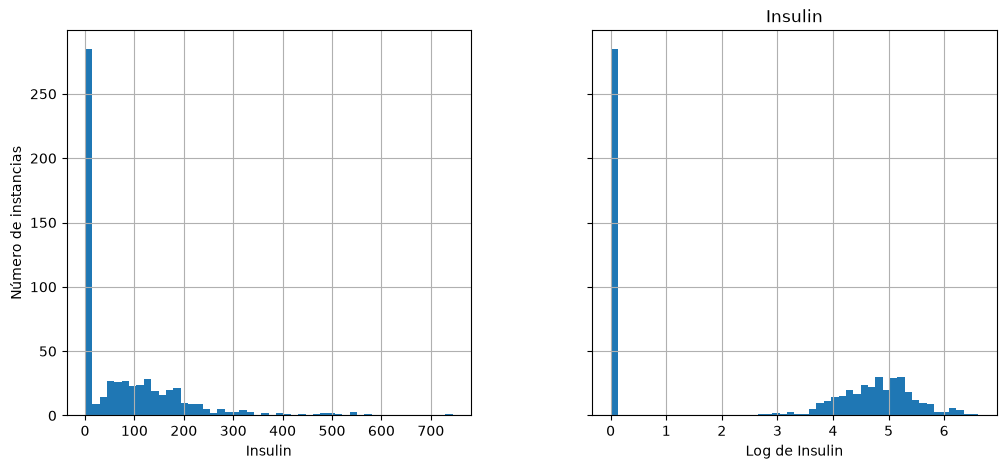

In [12]:
from sklearn.preprocessing import FunctionTransformer
#creamos un transformador
log_transformer = FunctionTransformer(
    np.log1p,
    inverse_func=np.expm1, #calcula la inversa (que es lo que queremos )
    feature_names_out="one-to-one" #el nombre de las caracteristicas 1 a 1
)
log_insulin = log_transformer.fit_transform(d_train[["Insulin"]]) 

fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
d_train["Insulin"].hist(ax=axs[0], bins=50)
log_insulin.hist(ax=axs[1], bins=50)
axs[0].set_xlabel("Insulin")
axs[1].set_xlabel("Log de Insulin")
axs[0].set_ylabel("Número de instancias")

plt.show()

La distribución de Insulin se vuelve más simétrica despues de la transformación logarítmica 

**Importante**: No hay atributo categórico en este dataset, por lo que no se incluye un pipeline categórico

## 3.Implementación del pipeline


In [13]:
def cero_a_nan(X):
    "Convierte los ceros (fisiologicamente imposibles) a NaN"
    X= np.asarray(X, dtype="float").copy() #copiamos el array para no modificar el original
    X[X == 0] = np.nan
    return X  

cero_a_nan_transformer = FunctionTransformer(cero_a_nan, feature_names_out="one-to-one")

In [14]:
from sklearn.compose import ColumnTransformer 
from sklearn.pipeline import Pipeline
from sklearn.pipeline import make_pipeline

ceros_invalidos= ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
insulina=["Insulin"]
ceros_validos= ["Pregnancies", "DiabetesPedigreeFunction", "Age"]

#pipeline para columnas numericas con ceros invalidos
ceros_invalidos_pipeline = Pipeline([
    ("cero_a_nan", cero_a_nan_transformer), #transformamos los ceros a nan
    ("impute", SimpleImputer(strategy="median")),
    ("standardize", StandardScaler()),
])

#pipeline para insulina --> ceros invalidos y sesgo
insulina_pipeline = Pipeline([
    ("cero_a_nan", cero_a_nan_transformer), #transformamos los ceros a nan
    ("impute", SimpleImputer(strategy="median")),
    ("log", FunctionTransformer(np.log1p, inverse_func=np.expm1, feature_names_out="one-to-one")), #transformamos a logaritmo
    ("standardize", StandardScaler()),
])

#pipelines para columnas numericas con ceros validos
ceros_validos_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("standardize", StandardScaler()),
])

#creamos pipeline para columnas categoricas --> no tenemos yo lo borraria
#cat_pipeline = make_pipeline(
#    SimpleImputer(strategy="most_frequent"), # usamos la categoria mas frencuente para imputar los valores
#    OneHotEncoder(handle_unknown="ignore") 
#    )

preprocessing = ColumnTransformer([ #usamos columntransformer para aplicar atributos numericos el pipeline numerico y a los categoricos el pipeline categoricos
    ("ceros_invalidos", ceros_invalidos_pipeline, ceros_invalidos),
    ("insulina", insulina_pipeline, insulina),
    ("ceros_validos", ceros_validos_pipeline, ceros_validos),
])
preprocessing

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('ceros_invalidos', ...), ('insulina', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`

El ColumnTransformer aplica un tratamiento distinto a cada grupo de columnas

# **Hasta aca llegue lo que sigue no lo vi ni lo toque**

In [16]:
d_num = d_train

d_num_prepared = num_pipeline.fit_transform(d_num) 
d_num_prepared[:2].round(2)

array([[-0.85, -0.98, -0.42, -0.59, -0.34, -0.62,  0.31, -0.79],
       [ 0.36,  0.16,  0.46,  0.37, -0.53, -0.31, -0.12,  0.56]])

In [17]:
num_pipeline.get_feature_names_out() 

array(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
       'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age'], dtype=object)

In [18]:
null_rows_idx = d_train.isnull().any(axis=1)

df_d_num_prepared = pd.DataFrame(
    d_num_prepared, columns=num_pipeline.get_feature_names_out(),index=d_num.index)
df_d_num_prepared[null_rows_idx] #el que transformamos 

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
33,0.658558,-0.916710,1.234806,0.116132,-0.735294,-1.565018,-0.876973,-0.453869
9,1.262524,0.129734,1.454917,0.116132,-0.335153,0.035377,-0.743652,1.745087
26,0.960541,0.827363,0.354364,0.116132,-0.735294,0.951732,-0.667902,0.814759
21,1.262524,-0.694737,0.794585,0.116132,-0.735294,0.435476,-0.270969,1.406786
22,0.960541,2.381173,1.124751,0.116132,-0.735294,1.003358,-0.080078,0.645609
10,0.054593,-0.345922,1.234806,0.116132,-0.335153,0.719417,-0.867883,-0.284718
12,1.866489,0.573680,0.574474,0.116132,-0.335153,-0.635756,2.919638,1.998812
7,1.866489,-0.187370,0.134253,0.116132,-0.335153,0.422569,-1.040594,-0.369293
15,0.960541,-0.663027,-3.827738,0.116132,-0.735294,-0.261470,0.019912,-0.115568
29,0.356576,-0.123950,1.234806,0.116132,-0.735294,0.267692,-0.425500,0.391883


Aplicamos transformer

In [19]:
df_d_prepared = preprocessing.fit_transform(d_train) #la transformacion la aplico sobre todo los datos de entrenamiento

In [20]:
preprocessing.get_feature_names_out()

array(['num__Pregnancies', 'num__Glucose', 'num__BloodPressure',
       'num__SkinThickness', 'num__Insulin', 'num__BMI',
       'num__DiabetesPedigreeFunction', 'num__Age'], dtype=object)

In [21]:
df_d_prepared = pd.DataFrame(
    df_d_prepared,
    columns=preprocessing.get_feature_names_out(),
    index=d_train.index)

df_d_prepared.head()

,num__Pregnancies,num__Glucose,num__BloodPressure,num__SkinThickness,num__Insulin,num__BMI,num__DiabetesPedigreeFunction,num__Age
353,-0.851355,-0.980131,-0.416023,-0.589225,-0.335153,-0.622850,0.310794,-0.792169
711,0.356576,0.161444,0.464419,0.372626,-0.530571,-0.313096,-0.116439,0.561034
373,-0.549372,-0.504474,-0.636134,1.206230,0.139433,0.370944,-0.764862,-0.707594
46,-0.851355,0.795653,-0.746189,-1.358705,-0.735294,-0.300190,0.262314,-0.369293
682,-1.153338,-0.821579,-0.305968,1.142106,0.241794,1.622866,-0.337630,-0.961320


In [23]:
df_d_prepared.shape

(614, 8)

In [ ]:
from sklearn.linear_model import LinearRegression #modelo de regresion lineal

lin_reg = make_pipeline(preprocessing, LinearRegression()) #creamos un pipeline con un estimador (modelo) de regresion lineal
lin_reg.fit(d_train, d_labels) #al fit en este caso hay que agregar si o si las etiquetas ya que es un entrenamiento

In [ ]:
d_predictions = lin_reg.predict(d_train)
d_predictions[:5].round() #hacemos una prediccion

In [ ]:
d_labels.iloc[:5].values #etiquetas reales

In [ ]:
from sklearn.tree import DecisionTreeRegressor #probamos otro modelo 

tree_reg = make_pipeline(preprocessing, DecisionTreeRegressor(random_state=42))
tree_reg.fit(d_train, d_labels)

# Aplicación del pipeline

#  Verificación del resultado